# EDA

Выгрузки Контур.Закупки, 07.07–14.07.2026

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Контур.Закупки_07.07.2026.xlsx to Контур.Закупки_07.07.2026.xlsx
Saving Контур.Закупки_08.07.2026.xlsx to Контур.Закупки_08.07.2026.xlsx
Saving Контур.Закупки_09.07.2026.xlsx to Контур.Закупки_09.07.2026.xlsx
Saving Контур.Закупки_10.07.2026.xlsx to Контур.Закупки_10.07.2026.xlsx
Saving Контур.Закупки_13.07.2026.xlsx to Контур.Закупки_13.07.2026.xlsx
Saving Контур.Закупки_14.07.2026.xlsx to Контур.Закупки_14.07.2026.xlsx


In [2]:
!pip install openpyxl -q

Структура одного файла


In [3]:
import openpyxl, glob

files_list = sorted(glob.glob('*.xlsx'))
print(files_list)

['Контур.Закупки_07.07.2026.xlsx', 'Контур.Закупки_08.07.2026.xlsx', 'Контур.Закупки_09.07.2026.xlsx', 'Контур.Закупки_10.07.2026.xlsx', 'Контур.Закупки_13.07.2026.xlsx', 'Контур.Закупки_14.07.2026.xlsx']


In [4]:
wb = openpyxl.load_workbook(files_list[0], data_only=True)
ws = wb['Лист1']
print(ws.dimensions)
headers = [c.value for c in ws[2]]
print(headers)

A1:AA10
['Номер', 'Название', 'НМЦ', 'Аванс', 'Валюта закупки', 'Дата публикации', 'Планируемая дата публикации', 'Окончание приема заявок', 'Проведение отбора', 'Этап отбора', 'Тип торгов', 'Ссылка на ЕИС', 'Способ отбора', 'ЭТП', 'СМП, СОНО', 'Размещает  закупку', 'Контактное лицо', 'Метка ', 'Комментарий', 'Ответственный', 'Регион', 'Название', 'ИНН', 'КПП', 'Телефон', 'Место поставки', 'Место поставки из документов']


Колонка "Название" встречается 2 раза - один раз название тендера, другой раз имя заказчика

Собираю все файлы в один список

In [5]:
headers = None
all_rows = []

for f in files_list:
    wb = openpyxl.load_workbook(f, data_only=True)
    ws = wb['Лист1']
    hdr_raw = [c.value for c in ws[2]]

    seen = {}
    hdr = []
    for h in hdr_raw:
        seen[h] = seen.get(h, 0) + 1
        hdr.append(h if seen[h] == 1 else f"{h} ({seen[h]})")
    if headers is None:
        headers = hdr

    for row in ws.iter_rows(min_row=3):
        vals = [c.value for c in row]
        if all(v in (None, '') for v in vals):
            continue
        rec = dict(zip(headers, vals))
        rec['_ссылка_на_карточку'] = row[0].hyperlink.target if row[0].hyperlink else None
        rec['_ссылка_на_этп'] = row[13].hyperlink.target if row[13].hyperlink else None
        rec['_файл'] = f
        all_rows.append(rec)

print('Всего строк:', len(all_rows))

Всего строк: 51


Убираю дубли между днями

In [6]:
import pandas as pd

seen_nums = {}
for r in all_rows:
    seen_nums.setdefault(r['Номер'], r)

df = pd.DataFrame(seen_nums.values())
print('Уникальных закупок:', len(df))

Уникальных закупок: 51


Тип торгов и метка

In [7]:
df['Тип торгов'].value_counts()

,count
Тип торгов,
Коммерческие,37
223-ФЗ,14


In [8]:
df['Метка '].value_counts()

,count
Метка,
Интересно,51


## Графики


In [9]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

График с типом торгов

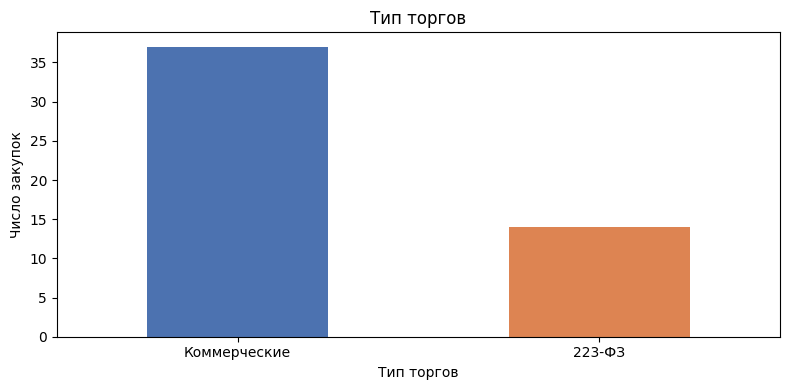

In [10]:
df['Тип торгов'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Тип торгов')
plt.ylabel('Число закупок')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_tip_torgov.png', dpi=150)
plt.show()

Способ отбора

In [11]:
df['Способ отбора'].value_counts()

,count
Способ отбора,
Тендер,10
Запрос предложений,8
Закупка иного способа размещения,5
Мониторинг цен,4
Конкурс в электронной форме,4
Запрос предложений в электронной форме,2
Другой тип конкурса,2
"Запрос предложений (закупка, с ЭП)",2
"Запрос предложений (закупка, без ЭП)",2


**19 разных значений на 51 строку, т.е. сильно разрежено.** Скорее всего буду группировать в 4-5 корзин: "Тендер/Конкурс", "Запрос предложений", "Запрос цен/котировок", "Отбор/предквалификация", "Прочее"

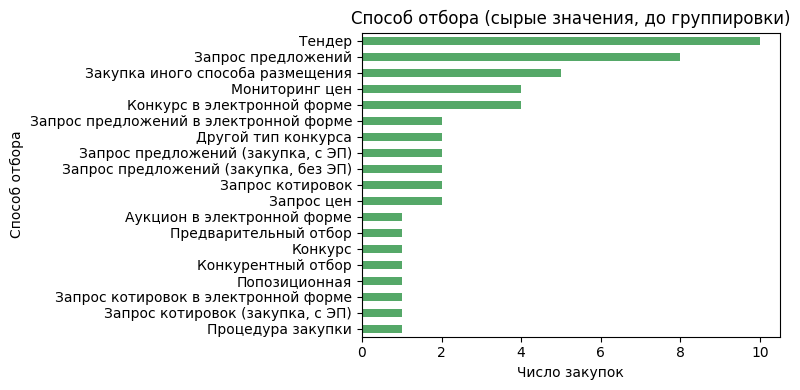

In [12]:
df['Способ отбора'].value_counts().plot(kind='barh', color='#55A868')
plt.title('Способ отбора (сырые значения, до группировки)')
plt.xlabel('Число закупок')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart_sposob_otbora.png', dpi=150)
plt.show()

Площадка и регион

In [13]:
df['ЭТП'].value_counts()

,count
ЭТП,
Росэлторг (ЕЭТП),12
B2B,8
Сбербанк-АСТ,7
Bidzaar,5
ЭТП ГПБ,5
РТС-тендер,5
ЭТП «Фабрикант»,4
ТЭК-Торг,3
РАД (Lot-Online),2


In [14]:
df['Регион'].value_counts().head(10)

,count
Регион,
77 Москва,32
78 Санкт-Петербург,5
13 Республика Мордовия,2
24 Красноярский край,2
66 Свердловская область,2
86 Ханты-Мансийский АО (Югра),2
50 Московская область,2
02 Республика Башкортостан,1
55 Омская область,1


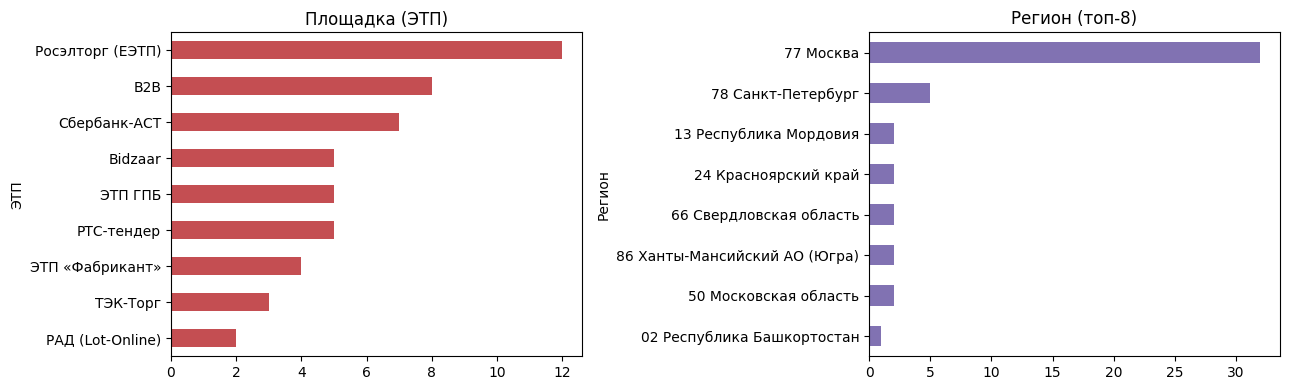

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['ЭТП'].value_counts().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Площадка (ЭТП)')
axes[0].invert_yaxis()

df['Регион'].value_counts().head(8).plot(kind='barh', ax=axes[1], color='#8172B2')
axes[1].set_title('Регион (топ-8)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('chart_etp_region.png', dpi=150)
plt.show()

Цена (НМЦ)

In [16]:
has_price = df['НМЦ'].notna() & (df['НМЦ'] != '')
print(f'{has_price.sum()} из {len(df)} строк с указанной ценой')

prices = pd.to_numeric(df.loc[has_price, 'НМЦ'], errors='coerce').dropna()
prices.describe()

25 из 51 строк с указанной ценой


,НМЦ
count,2.500000e+01
mean,3.157189e+07
std,5.498645e+07
min,1.376000e+05
25%,4.840000e+06
50%,1.500000e+07
75%,4.040435e+07
max,2.755704e+08


**25 из 51** строк с указанной ценой. Разброс на порядки тут от 137600 руб до 275,5 млн руб. Как признак цену думаю нужно логарифмировать

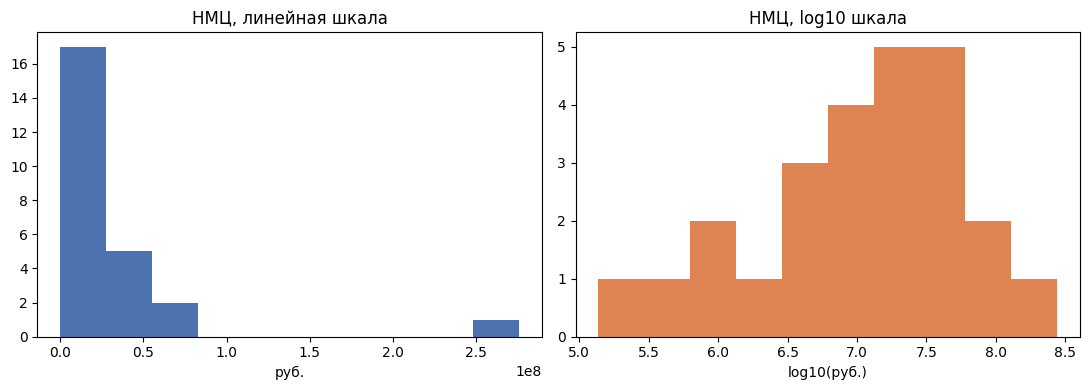

In [17]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(prices, bins=10, color='#4C72B0')
axes[0].set_title('НМЦ, линейная шкала')
axes[0].set_xlabel('руб.')

axes[1].hist(np.log10(prices), bins=10, color='#DD8452')
axes[1].set_title('НМЦ, log10 шкала')
axes[1].set_xlabel('log10(руб.)')

plt.tight_layout()
plt.savefig('chart_nmc.png', dpi=150)
plt.show()

**Вывод**: на линейной шкале почти все точки прижаты к нулю, а на log-шкале распределение выглядит куда равномернее, т.е. для модели нужен именно логарифм цены

Сроки на подачу заявки

In [18]:
pub = pd.to_datetime(df['Дата публикации'])
deadline = pd.to_datetime(df['Окончание приема заявок'])
days = (deadline - pub).dt.days
days.describe()

,0
count,51.00000
mean,13.72549
std,29.65743
min,2.00000
25%,7.00000
50%,7.00000
75%,14.50000
max,219.00000


In [19]:
# Выброс
print(df.loc[days.idxmax(), ['Номер','Название','Способ отбора']])

Номер                                                     ГП619694
Название         Открытый квалификационный отбор № КО26-01-01, ...
Способ отбора                                Предварительный отбор
Name: 18, dtype: object


**Медиана - 7 дней**, разброс 2-20 дней у 50 из 51 строк. Один явный выброс - **219 дней**, т.е. это "открытый квалификационный отбор" со способом "gредварительный отбор"

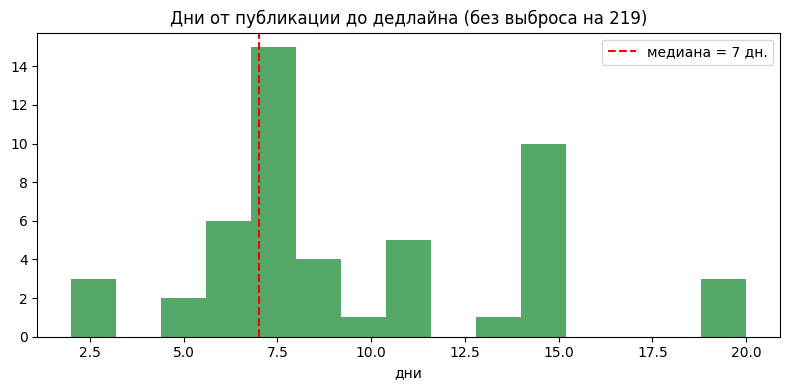

In [20]:
plt.figure(figsize=(8,4))
plt.hist(days[days < 50], bins=15, color='#55A868')  # без выброса на 219, чтобы увидеть основную массу
plt.axvline(days.median(), color='red', linestyle='--', label=f'медиана = {days.median():.0f} дн.')
plt.title('Дни от публикации до дедлайна (без выброса на 219)')
plt.xlabel('дни')
plt.legend()
plt.tight_layout()
plt.savefig('chart_days.png', dpi=150)
plt.show()

О чём говорят названия закупок

In [21]:
import re
from collections import Counter

stop = {'и','в','о','на','с','для','по','от','к','у','из','как','что','это','или',
        'не','при','об','до','через','между','над','под','нужд','право','заключения',
        'договора','оказание','услуг','работ','выполнение','проведение'}

words = Counter()
for title in df['Название']:
    t = re.sub(r'[^а-яa-z0-9\-]+', ' ', str(title).lower())
    for w in t.split():
        if len(w) >= 4 and w not in stop:
            words[w] += 1

for w, c in words.most_common(30):
    print(c, w)

29 системы
10 информационной
8 внедрению
8 обеспечения
8 технической
7 услуги
7 сопровождению
7 программного
7 доработке
7 поддержке
7 запрос
6 модернизации
6 управления
6 разработке
6 данных
5 автоматизированной
5 работы
4 автоматизации
4 пользователей
4 разработки
4 платформы
4 поддержки
4 процессов
4 группы
4 комплексной
4 реализации
4 части
4 систем
4 открытый
4 сервисов


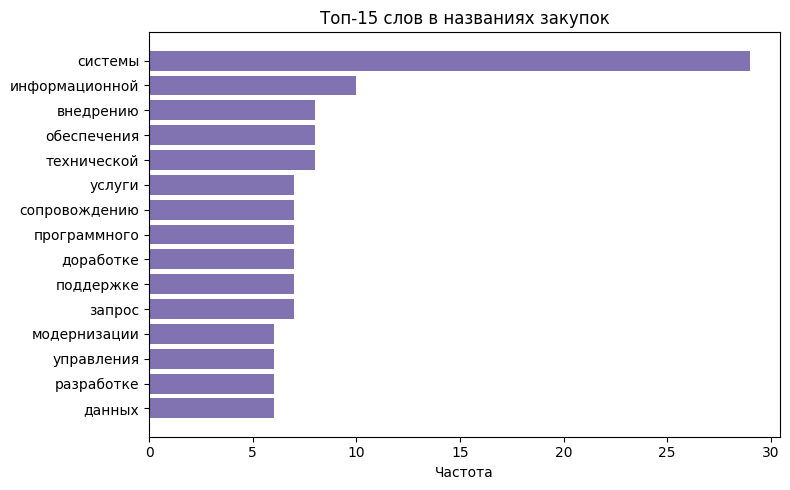

In [22]:
top_words = words.most_common(15)
labels, counts = zip(*top_words)

plt.figure(figsize=(8,5))
plt.barh(labels, counts, color='#8172B2')
plt.gca().invert_yaxis()
plt.title('Топ-15 слов в названиях закупок')
plt.xlabel('Частота')
plt.tight_layout()
plt.savefig('chart_top_words.png', dpi=150)
plt.show()

Ключевики

Точные фразы ИЛИ корни слов

In [23]:
uploaded_kw = files.upload()

Saving keywords.txt to keywords.txt


In [24]:
kw_filename = list(uploaded_kw.keys())[0]
keywords = [k.strip().lower() for k in open(kw_filename, encoding='utf-8')]

def has_exact_match(title):
    t = str(title).lower().replace(' ', '')
    return any(k.replace(' ', '') in t for k in keywords)

hit = df['Название'].apply(has_exact_match).sum()
print(f'{hit} из {len(df)} по точным фразам')

11 из 51 по точным фразам


In [25]:
roots = ['сайт','информацион','систем','программ','приложен','платформ','модерниз',
         'внедр','разработ','доработ','автоматиз','портал']

def has_root_match(title):
    t = str(title).lower()
    return any(r in t for r in roots)

hit2 = df['Название'].apply(has_root_match).sum()
print(f'{hit2} из {len(df)} по корням')

49 из 51 по корням


Вывод для признаков: **TF-IDF нужно строить на стеммированных/лемматизированных токенах**, иначе шаблон ключевиков почти не даст сигнала



# Сравнение интересных и неинтересных (все предложения)
Беру уже собранный `dataset_labeled_full.csv`, ггде 2117 строк, колонка `label`: 1 = интересно, 0 = нет

In [26]:
from google.colab import files
uploaded = files.upload()

Saving dataset_labeled_full.csv to dataset_labeled_full.csv


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

full = pd.read_csv('dataset_labeled_full.csv', sep=';', encoding='utf-8-sig')
print(len(full), 'строк')
full['label'].value_counts()

2117 строк


,count
label,
0,1967
1,150


150 из 2117 помечены как интересные (label=1), остальные 1967 - нет

Дальше сравниваю эти две группы между собой

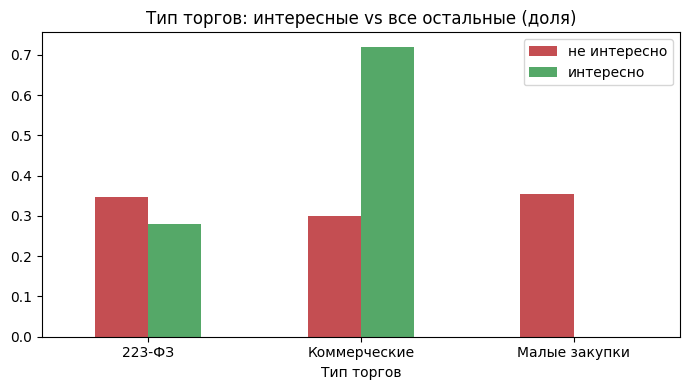

In [28]:
fig, ax = plt.subplots(figsize=(7,4))
share = full.groupby('label')['Тип торгов'].value_counts(normalize=True).unstack()
share.T.plot(kind='bar', ax=ax, color=['#C44E52', '#55A868'])
ax.set_title('Тип торгов: интересные vs все остальные (доля)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['не интересно', 'интересно'])
plt.tight_layout()
plt.savefig('chart_compare_tip_torgov.png', dpi=150)
plt.show()

Смотрю на разницу в долях - если 223-ФЗ среди интересных встречается заметно чаще, чем среди всех остальных, это уже полезный сигнал для модели по предыдущему EDA

In [29]:
import numpy as np

price_all = pd.to_numeric(full['НМЦ'], errors='coerce')
has_price_interesting = price_all[full['label']==1].notna().mean()
has_price_other = price_all[full['label']==0].notna().mean()
print(f'Цена указана среди интересных: {has_price_interesting:.1%}')
print(f'Цена указана среди остальных: {has_price_other:.1%}')

Цена указана среди интересных: 49.3%
Цена указана среди остальных: 81.1%


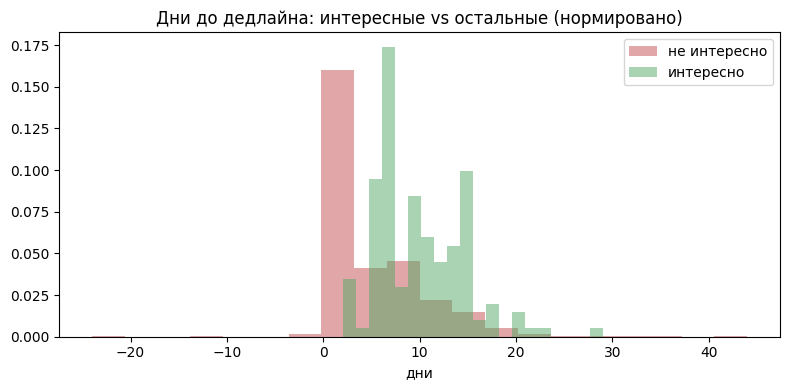

In [30]:
pub = pd.to_datetime(full['Дата публикации'], errors='coerce')
deadline = pd.to_datetime(full['Окончание приема заявок'], errors='coerce')
days_full = (deadline - pub).dt.days

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(days_full[(full['label']==0) & (days_full<60)], bins=20, alpha=0.5, label='не интересно', color='#C44E52', density=True)
ax.hist(days_full[(full['label']==1) & (days_full<60)], bins=20, alpha=0.5, label='интересно', color='#55A868', density=True)
ax.set_title('Дни до дедлайна: интересные vs остальные (нормировано)')
ax.set_xlabel('дни')
ax.legend()
plt.tight_layout()
plt.savefig('chart_compare_days.png', dpi=150)
plt.show()

Смотрю, не отличаются ли интересные тендеры по срокам подачи от всех остальных

Если распределения похожи, этот признак сам по себе слабый, но в связке с другими всё равно может быть полезным

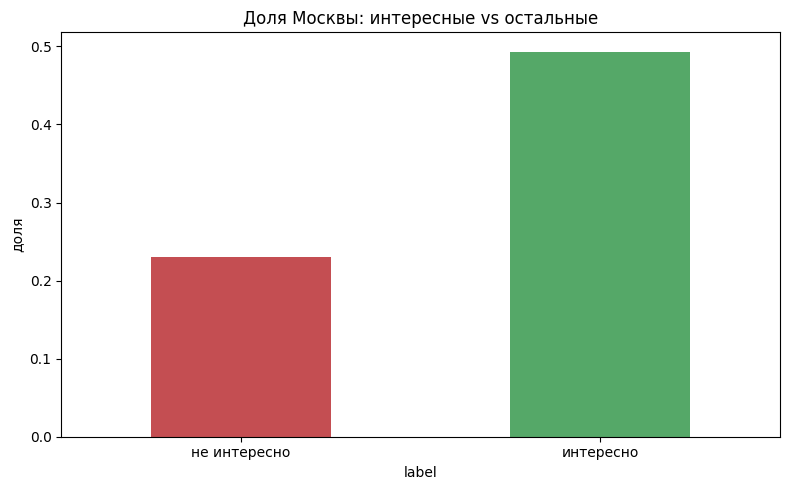

In [31]:
fig, ax = plt.subplots(figsize=(8,5))
share_region = full.assign(москва=full['Регион'].astype(str).str.contains('Москва')).groupby('label')['москва'].mean()
share_region.plot(kind='bar', ax=ax, color=['#C44E52','#55A868'])
ax.set_xticklabels(['не интересно','интересно'], rotation=0)
ax.set_title('Доля Москвы: интересные vs остальные')
ax.set_ylabel('доля')
plt.tight_layout()
plt.savefig('chart_compare_moscow.png', dpi=150)
plt.show()